# P13. Melt, Density, and Bulk Dissipation

A material with a solid and a liquid phase melts between its solidus and liquidus, and its melt-weakening law lowers the shear modulus and viscosity as it does. By default that is all melt changes. Three other effects of melt each have their own setting, all off by default:

| Setting | Where | Effect |
|---|---|---|
| `use_melt_density` | layer switch | The density mixes the liquid phase's density in by melt fraction, and the structure solve integrates it. |
| `bulk_modulus_mixing = "hashin_shtrikman"` | material's `melting` table | The bulk modulus is the two-phase (Hashin-Shtrikman) bound, using the liquid phase's bulk modulus at the local pressure. |
| `bulk_viscosity_mixing = "compaction"` | material's `melting` table | Melt sets a compaction bulk viscosity, $c\,\eta/\phi^n$, in series with the solid's. |

The melt is the material's liquid phase, with its own equation of state. A bulk viscosity only dissipates through a non-elastic bulk rheology. The Zener (standard linear solid) rheology is the appropriate choice, since it relaxes to a set fraction of the bulk modulus rather than to zero.

This notebook:

1. Compares the Zener and Maxwell rheologies.
2. Follows one material point through its melting range with each setting.
3. Applies the settings to Io with a partially molten asthenosphere.
4. Shows why a Maxwell bulk rheology is misleading, and when a bulk response matters at all.
5. Shows how mixing the melt into the density changes the structure.

In [1]:
%matplotlib inline
import copy
import math

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.Material import make_material
from TidalPy.Rheology import maxwell, zener
from TidalPy.Structures import build_world

DAY = 86400.0
IO_FREQUENCY = 2.0 * math.pi / (1.769138 * DAY)  # Io's orbital mean motion [rad/s]
IO_ECCENTRICITY, IO_SEMI_MAJOR_AXIS, JUPITER_MASS = 0.0041, 4.217e8, 1.898e27

## Zener and Maxwell

The Zener rheology is a spring with the relaxed modulus $rM$ in parallel with a Maxwell arm that holds the rest, $(1 - r)M$:

$$M^{*} = rM + (1 - r)M\,\frac{i\omega\tau}{1 + i\omega\tau}, \qquad \tau = \frac{\eta}{(1 - r)M}.$$

At high frequency it is $M$. At low frequency it relaxes to $rM$, whereas a Maxwell body relaxes to zero. $r = 0$ is Maxwell. Below, each curve is plotted against $\omega\tau$, so the loss peaks line up at 1.

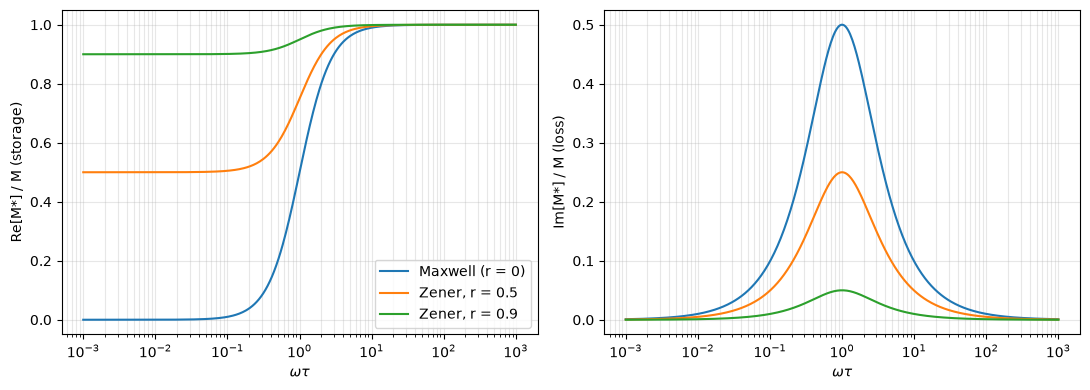

In [2]:
modulus, viscosity = 1.0, 1.0
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
omega_tau = np.logspace(-3, 3, 400)
for r in (0.0, 0.5, 0.9):
    # tau = eta / ((1 - r) M), so omega = omega_tau (1 - r) M / eta. r = 0 is Maxwell.
    frequency = omega_tau * (1.0 - r) * modulus / viscosity
    response = zener(modulus, viscosity, frequency, relaxed_modulus_frac=r)
    label = "Maxwell (r = 0)" if r == 0.0 else f"Zener, r = {r}"
    axes[0].semilogx(omega_tau, response.real, label=label)
    axes[1].semilogx(omega_tau, response.imag, label=label)
assert np.allclose(zener(1.0, 1.0, 0.7, relaxed_modulus_frac=0.0), maxwell(1.0, 1.0, 0.7))
axes[0].set_ylabel("Re[M*] / M (storage)")
axes[1].set_ylabel("Im[M*] / M (loss)")
for ax in axes:
    ax.set_xlabel(r"$\omega\tau$")
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend()
plt.tight_layout()

## One Material Point Through Its Melting Range

Io's asthenosphere material (a Birch-Murnaghan rock with the peridotite melting curves, a peridotite melt as its liquid phase, and Henning weakening) is evaluated at 0.3 GPa (mid-asthenosphere) from 1600 to 2100 K, with each setting off and on. At this pressure the solidus is 1707 K and the liquidus 1999 K. Io's file gives the asthenosphere rock no bulk viscosity (its bulk response is elastic), so a solid bulk viscosity of $10^{22}$ Pa s is added here for the compaction law to start from. Like Io's layers, the sweep uses melting with pressure-dependent curves and no thermal expansion. `Material.calc_state` is the same evaluation the equation-of-state solve uses.

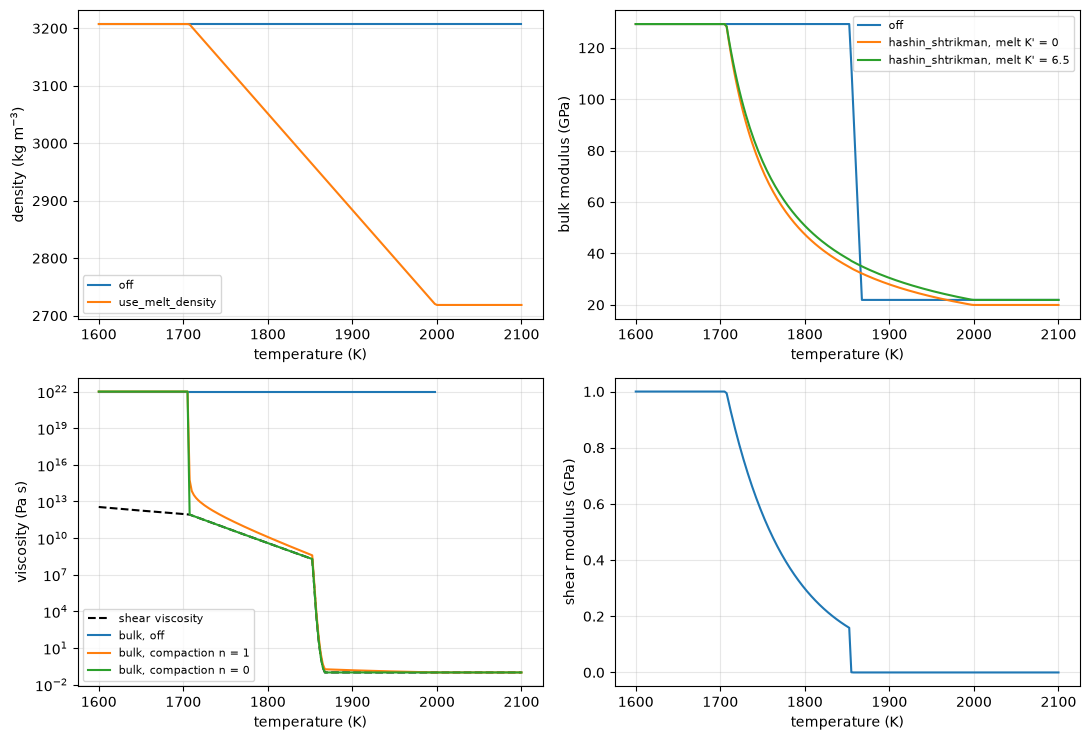

solidus 1707 K, liquidus 1999 K at 0.3 GPa; melt fraction runs from 0.00 to 1.00
without mixing, the bulk modulus drops at 1862 K, melt fraction 0.53


In [3]:
io_config = build_world("io").get_config_dict()
SOLID_BULK_VISCOSITY = {"model": "constant", "reference_viscosity_pas": 1.0e22}
asthenosphere_material = io_config["layers"]["asthenosphere"]["material"]
asthenosphere_material["solid"]["bulk_viscosity"] = SOLID_BULK_VISCOSITY

HASHIN_SHTRIKMAN = {"bulk_modulus_mixing": {"model": "hashin_shtrikman"}}
COMPACTION = {"bulk_viscosity_mixing": {"model": "compaction"}}


def material(melt_bulk_modulus_derivative=None, **melting):
    """Io's asthenosphere material with the given entries added to its melting table."""
    config = copy.deepcopy(asthenosphere_material)
    config["melting"].update(melting)
    if melt_bulk_modulus_derivative is not None:
        config["liquid"]["eos"]["bulk_modulus_derivative"] = melt_bulk_modulus_derivative
    return make_material(config)


pressure = 3.0e8
temperatures = np.linspace(1600.0, 2100.0, 201)


def sweep(model, key, use_melt_density=False):
    state = model.calc_state(pressure, temperatures, use_melting=True, use_pressure_melting=True,
                             use_melt_density=use_melt_density)
    return state[key]


off = material()
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes[0, 0].plot(temperatures, sweep(off, "density"), label="off")
axes[0, 0].plot(temperatures, sweep(off, "density", use_melt_density=True), label="use_melt_density")
axes[0, 0].set_ylabel("density (kg m$^{-3}$)")
bulk_modulus_off = sweep(off, "bulk_modulus")
axes[0, 1].plot(temperatures, bulk_modulus_off / 1e9, label="off")
axes[0, 1].plot(temperatures, sweep(material(melt_bulk_modulus_derivative=0.0, **HASHIN_SHTRIKMAN),
                                    "bulk_modulus") / 1e9, label="hashin_shtrikman, melt K' = 0")
axes[0, 1].plot(temperatures, sweep(material(**HASHIN_SHTRIKMAN), "bulk_modulus") / 1e9,
                label="hashin_shtrikman, melt K' = 6.5")
axes[0, 1].set_ylabel("bulk modulus (GPa)")
axes[1, 0].semilogy(temperatures, sweep(off, "shear_viscosity"), "k--", label="shear viscosity")
axes[1, 0].semilogy(temperatures, sweep(off, "bulk_viscosity"), label="bulk, off")
for exponent in (1.0, 0.0):
    model = material(bulk_viscosity_mixing={"model": "compaction", "exponent": exponent})
    axes[1, 0].semilogy(temperatures, sweep(model, "bulk_viscosity"), label=f"bulk, compaction n = {exponent:g}")
axes[1, 0].set_ylabel("viscosity (Pa s)")
axes[1, 1].plot(temperatures, sweep(off, "shear_modulus") / 1e9)
axes[1, 1].set_ylabel("shear modulus (GPa)")
melt_fraction = sweep(off, "melt_fraction")
for ax in axes.flat:
    ax.set_xlabel("temperature (K)")
    ax.grid(True, alpha=0.3)
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
solidus, liquidus = off.calc_melting_range(pressure)
print(f"solidus {solidus:.0f} K, liquidus {liquidus:.0f} K at {pressure/1e9:.1f} GPa; "
      f"melt fraction runs from {melt_fraction.min():.2f} to {melt_fraction.max():.2f}")
drop = np.argmax(bulk_modulus_off < 0.5 * bulk_modulus_off[0])  # First point below half the solid's value
print(f"without mixing, the bulk modulus drops at {temperatures[drop]:.0f} K, melt fraction {melt_fraction[drop]:.2f}")

Each setting acts from the solidus on:

- **Density.** Silicate melt is lighter than the rock at this pressure, so the mixture's density falls as it melts. The melt is more compressible than the rock, so deep enough the melt can become the denser phase (the density crossover of silicate melts). The mixture handles either case.
- **Bulk modulus.** A solid framework stiffens the aggregate through its shear modulus, but Io's fitted asthenosphere has only $10^9$ Pa of it. The Hashin-Shtrikman bound then sits close to the Reuss average of a suspension from the first melt, and the bulk modulus falls steeply toward the melt's. Without a mixing law the solid's bulk modulus holds until the Henning breakdown band (50 to 55% melt), where it drops to the melt's, at 1862 K and a melt fraction of 0.53 here. A pressure-dependent melt ($K' = 6.5$) is stiffer than a constant one at any positive pressure, so it weakens the rock less.
- **Bulk viscosity.** Without melt it is the solid's value, $10^{22}$ Pa s here. Melt lowers it to the compaction value. McKenzie's $n = 1$ keeps it a factor $1/\phi$ above the shear viscosity. $n = 0$ sets it equal to the shear viscosity. The liquid phase has no bulk viscosity, so the `off` curve ends at the liquidus.
- **Shear modulus.** It falls with melt, and past the critical melt fraction the Henning law collapses the shear modulus and viscosity to the liquid's (zero rigidity).

## Io With a Partially Molten Asthenosphere

The bundled Io keeps its asthenosphere at 1600 K, below its solidus, with no melt. At 1725 K its top 76 km are partially molten, up to 20% at the top (the solidus rises with pressure, so the base stays solid). The table below gives $k_2$ at the orbital period, its quality factor `love_q_k` ($Q = |k_2| / (-\mathrm{Im}\,k_2)$), and the tidal heating, adding one setting at a time. Each world is the bundled Io with its asthenosphere changed through `build_world`'s `overrides`, a nested dictionary merged onto the file's configuration. The mass is not refitted, so it follows whatever density the settings give.

In [4]:
def io_world(temperature=1725.0, bulk_rheology=None, use_melt_density=False, **melting):
    """The bundled Io with its asthenosphere at a temperature [K] and with the given settings, solved."""
    asthenosphere = {
        "temperature_k": temperature,
        "use_melt_density": use_melt_density,
        "material": {"solid": {"bulk_viscosity": SOLID_BULK_VISCOSITY}, "melting": melting}}
    if bulk_rheology is not None:
        asthenosphere["bulk_rheology"] = bulk_rheology
    world = build_world("io", overrides={"layers": {"asthenosphere": asthenosphere}})
    world.solve_eos(raise_on_fail=True)
    return world


def love_k2(world, frequency=IO_FREQUENCY):
    world.solve_love_numbers(frequency, degree_l=2, raise_on_fail=True)
    return world.love_number_k


def heating(world):
    tides = world.calc_tides(IO_FREQUENCY, IO_FREQUENCY, IO_ECCENTRICITY, 0.0, IO_SEMI_MAJOR_AXIS, JUPITER_MASS)
    return tides["tidal_heating"]  # [W]


ZENER = {"model": "zener", "relaxed_modulus_frac": 0.5}
BULK = dict(**HASHIN_SHTRIKMAN, **COMPACTION)
warm_layer = io_world().asthenosphere
layer_radii = np.linspace(warm_layer.radius_inner, warm_layer.radius_outer, 2001)
layer_melt = warm_layer.get_melt_fraction(layer_radii)
melt_depth = warm_layer.radius_outer - layer_radii[layer_melt > 0.0].min()  # [m]
print(f"at 1725 K the asthenosphere melts above {melt_depth/1e3:.0f} km depth, up to {layer_melt.max():.3f} at its top")
cases = [
    ("bundled Io (1600 K, no melt)", dict(temperature=1600.0)),
    ("shear melt weakening only", dict()),
    ("+ hashin_shtrikman", dict(**HASHIN_SHTRIKMAN)),
    ("+ compaction, Zener r = 0.5", dict(bulk_rheology=ZENER, **BULK)),
    ("+ compaction, Maxwell", dict(bulk_rheology={"model": "maxwell"}, **BULK)),
    ("+ use_melt_density (with Zener)", dict(bulk_rheology=ZENER, use_melt_density=True, **BULK)),
]
print(f"{'case':38s} {'Re k2':>8s} {'-Im k2':>8s} {'Q':>6s} {'heating [W]':>12s} {'mass [kg]':>11s}")
for label, kwargs in cases:
    world = io_world(**kwargs)
    k2 = love_k2(world)
    quality_factor = world.love_q_k
    print(f"{label:38s} {k2.real:8.4f} {-k2.imag:8.4f} {quality_factor:6.2f} {heating(world):12.3e} "
          f"{world.planet_mass_eos:11.4e}")

at 1725 K the asthenosphere melts above 76 km depth, up to 0.199 at its top
case                                      Re k2   -Im k2      Q  heating [W]   mass [kg]
bundled Io (1600 K, no melt)             0.0357   0.0150   2.58    9.329e+13  8.9298e+22
shear melt weakening only                0.0481   0.1070   1.10    6.654e+14  8.9298e+22
+ hashin_shtrikman                       0.0481   0.1070   1.10    6.653e+14  8.9298e+22
+ compaction, Zener r = 0.5              0.0481   0.1070   1.10    6.653e+14  8.9298e+22
+ compaction, Maxwell                    0.0569   0.0893   1.19    5.555e+14  8.9298e+22
+ use_melt_density (with Zener)          0.0477   0.1053   1.10    6.549e+14  8.9135e+22


- **Against Juno.** The bundled Io is fitted only to Io's heat output, so its $k_2$ and $Q$ are model results. Park et al. (2025) measured Re $k_2 = 0.125 \pm 0.047$ and $Q = 11.4 \pm 3.6$ (1 sigma). The bundled Io's Re $k_2$ = 0.036 is about 2 sigma below that, and its $Q$ = 2.6 about 2.5 sigma below, while its $-\mathrm{Im}\,k_2$ = 0.015 is close to the measured $k_2 / Q \approx 0.011$. The model deforms less than Io and dissipates a larger fraction of each tidal cycle. Melting the asthenosphere raises Re $k_2$ a little but lowers $Q$ further.
- **Shear weakening.** Melting the top 76 km of the asthenosphere (up to 20% at its top) multiplies the heating by about seven.
- **Bulk modulus.** The Hashin-Shtrikman bulk modulus changes $k_2$ only in the fifth decimal place.
- **Zener bulk viscosity.** With a Zener bulk rheology the melt's bulk viscosity has no effect in the digits shown.
- **Maxwell bulk viscosity.** With a Maxwell bulk rheology the heating falls by 17% and Re $k_2$ rises by 18%. This comes from the bulk modulus relaxing to nearly zero, not from real bulk dissipation.
- **Density mixing.** Mixing in the lighter melt lowers the asthenosphere's density by up to 3% at its top. With the radii fixed, Io then has 0.18% less mass, which a real model would refit.

## Maxwell Against Zener Across Forcing Periods

A Maxwell bulk rheology relaxes the bulk modulus toward zero for forcing slower than $\zeta / K$, about 4 s at the top of this layer and longer where it melts less. At tidal periods the Maxwell layer has almost no bulk stiffness left where it melts, and from a few days on its $k_2$ departs far from the elastic result. A Zener bulk rheology keeps at least a fraction $r$ of the unrelaxed modulus and tracks the elastic result. The grey line is Io's orbital period. `calc_love_numbers` solves the Love numbers at each frequency of an array. The sweep stops at 100 days: past that the Maxwell layer is so soft in bulk and shear that the radial solve loses its accuracy (TidalPy warns of a poorly conditioned surface solve).

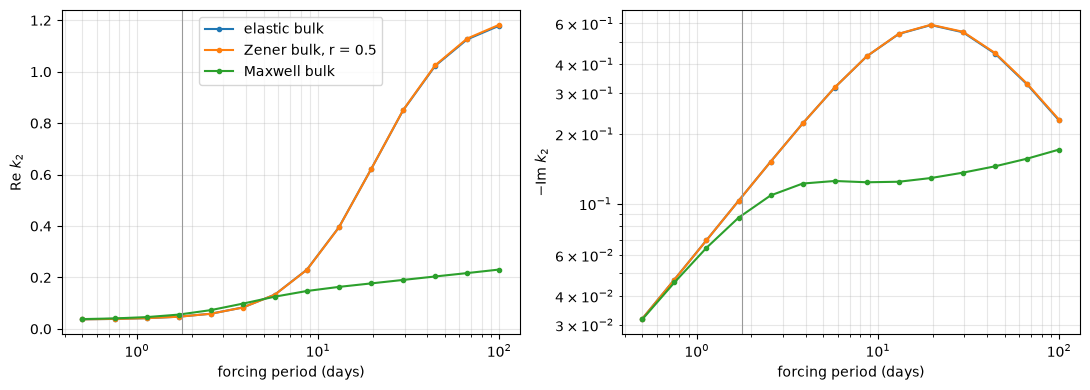

In [5]:
periods = np.logspace(np.log10(0.5), 2.0, 14)  # [days]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, rheology in (("elastic bulk", {"model": "elastic"}), ("Zener bulk, r = 0.5", ZENER),
                        ("Maxwell bulk", {"model": "maxwell"})):
    world = io_world(bulk_rheology=rheology, **BULK)
    k2 = world.calc_love_numbers(2.0 * math.pi / (periods * DAY))["k"]  # One solve per period, NaN if it fails
    axes[0].semilogx(periods, k2.real, "o-", ms=3, label=label)
    axes[1].loglog(periods, -k2.imag, "o-", ms=3, label=label)
axes[0].set_ylabel("Re $k_2$")
axes[1].set_ylabel("$-$Im $k_2$")
for ax in axes:
    ax.set_xlabel("forcing period (days)")
    ax.axvline(1.769138, color="0.6", lw=0.8)
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

## When Does a Bulk Response Matter?

Bulk dissipation per unit volume scales as $\mathrm{Im}[K^*]\,|\nabla\cdot\mathbf{u}|^2$ and the volumetric strain as stress over $|K^*|$, so a layer's bulk dissipation scales as $\mathrm{Im}[K^*]/|K^*|^2$. A layer much stiffer in bulk than in shear is nearly incompressible, and its bulk response hardly matters. Io's fitted asthenosphere has a shear modulus below $10^9$ Pa and a bulk modulus of 62 to 130 GPa, which is why the Zener rows above did not change.

The bulk response matters when the relaxed bulk modulus $rK$ approaches the shear modulus. Physically this is a drained modulus far below the undrained one, e.g., when melt films let the framework compact freely. Below, $r$ and the compaction coefficient $c$ are swept at Io's orbital period. Each point is Re $k_2$ or $-$Im $k_2$ divided by its elastic-bulk value.

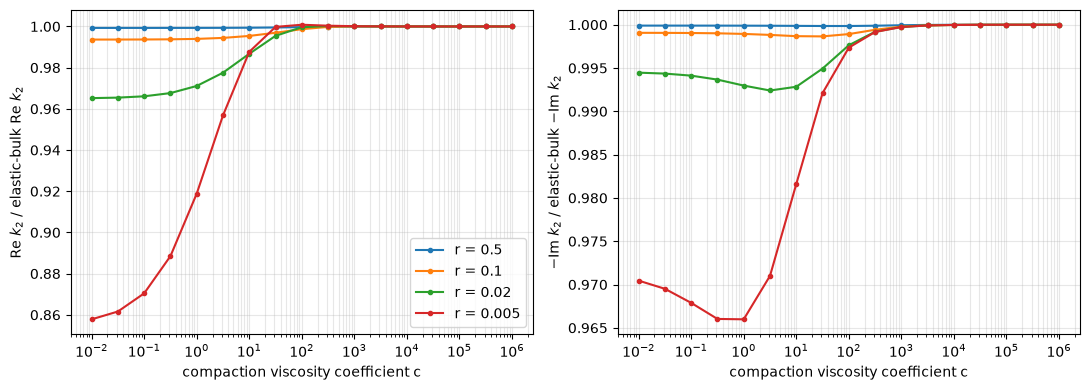

In [6]:
reference = love_k2(io_world(**HASHIN_SHTRIKMAN))
coefficients = np.logspace(-2, 6, 17)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for r in (0.5, 0.1, 0.02, 0.005):
    ratios = []
    for c in coefficients:
        world = io_world(bulk_rheology={"model": "zener", "relaxed_modulus_frac": r},
                         **HASHIN_SHTRIKMAN, bulk_viscosity_mixing={"model": "compaction", "coefficient": c})
        ratios.append(love_k2(world))
    ratios = np.array(ratios)
    axes[0].semilogx(coefficients, ratios.real / reference.real, "o-", ms=3, label=f"r = {r}")
    axes[1].semilogx(coefficients, ratios.imag / reference.imag, "o-", ms=3, label=f"r = {r}")
axes[0].set_ylabel("Re $k_2$ / elastic-bulk Re $k_2$")
axes[1].set_ylabel("$-$Im $k_2$ / elastic-bulk $-$Im $k_2$")
for ax in axes:
    ax.set_xlabel("compaction viscosity coefficient c")
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

- **Moderate relaxation ($r = 0.5$).** No change.
- **Strong relaxation ($r = 0.005$, a relaxed bulk modulus of a few $10^8$ Pa).** At small $c$ the compaction relaxes within a forcing cycle and the molten part of the layer becomes compressible. Re $k_2$ falls by up to about 14% and the global $-$Im $k_2$ by up to about 3%.
- **Sign of the change.** The layer does add bulk dissipation, but becoming compressible also redistributes its strain. Here that costs more shear dissipation than the bulk response adds.
- **Large $c$.** The compaction viscosity is so large that the bulk response never relaxes, and every curve returns to 1.

How much bulk dissipation matters depends on the interior. Kervazo et al. (2021) found it can rival shear dissipation in a partially molten Io. This fitted model, with its very weak shear modulus, is close to the opposite limit.

## Density Mixing and the Structure

With `use_melt_density = True` the structure solve integrates the mixture density, so the melt changes gravity, pressure, and the reported mass. `get_density` uses the same evaluation, so it returns exactly the density the solve integrated.

use_melt_density False: asthenosphere mass 1.2650e+22 kg, Io 8.92980e+22 kg, melt fraction 0.325 at mid-layer
use_melt_density True : asthenosphere mass 1.1997e+22 kg, Io 8.86300e+22 kg, melt fraction 0.332 at mid-layer


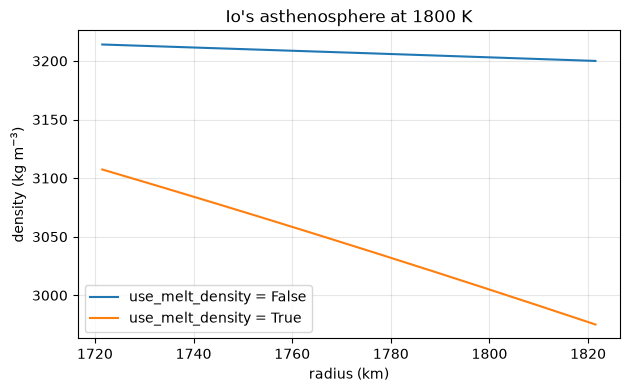

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for melt_density in (False, True):
    world = io_world(temperature=1800.0, use_melt_density=melt_density)
    layer = world.asthenosphere
    radii = np.linspace(layer.radius_inner, layer.radius_outer, 200)
    ax.plot(radii / 1e3, layer.get_density(radii), label=f"use_melt_density = {melt_density}")
    print(f"use_melt_density {str(melt_density):5s}: asthenosphere mass {layer.mass:.4e} kg, "
          f"Io {world.planet_mass_eos:.5e} kg, melt fraction {layer.get_melt_fraction(radii[100]):.3f} at mid-layer")
ax.set_xlabel("radius (km)")
ax.set_ylabel("density (kg m$^{-3}$)")
ax.set_title("Io's asthenosphere at 1800 K")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

A world fitted to its mass without mixing loses mass when mixing is turned on, so turn it on before fitting. If a layer's melt fraction follows a solved temperature profile, its density is coupled to its temperature and the thermal solve takes more iterations to converge.

## Summary

| Setting | Default | What it changes | When it matters |
|---|---|---|---|
| `use_melt_density` (layer) | off | The structure: density, gravity, pressure, mass | Any appreciable melt. Refit the mass with it on. |
| `bulk_modulus_mixing` (material) | none | The unrelaxed bulk modulus | Little on its own. It sets the bulk rheology's unrelaxed modulus. |
| `bulk_viscosity_mixing` (material) | none | The bulk viscosity, through the bulk rheology | Only with a non-elastic bulk rheology, and only when the relaxed bulk modulus nears the shear modulus |

Use a Zener bulk rheology, not Maxwell, whenever the bulk viscosity is finite. Maxwell lets the bulk modulus relax to zero, which no rock does.

**References.** McKenzie (1984), J. Petrol. 25, 713; Park et al. (2025), Nature 638, 69; Takei and Holtzman (2009), JGR 114, B06205; Hashin and Shtrikman (1963), J. Mech. Phys. Solids 11, 127; Kervazo et al. (2021), A&A 650, A72; Nowick and Berry (1972), Anelastic Relaxation in Crystalline Solids.